### Neural Networks: The Nine-Step Guide to Building Your Own Neural Network

Datasets: MNIST dataset

Neural Networks are a powerful tool in machine learning, capable of modeling complex relationships in data. In this guide, we will walk through the nine essential steps to build your own neural network using the MNIST dataset, which consists of handwritten digit images.

The MNIST dataset is a widely used benchmark in the field of machine learning and computer vision. It contains 60,000 training images and 10,000 testing images of handwritten digits (0-9). Each image is a 28x28 pixel grayscale image, which can be flattened into a 784-dimensional vector for input into a neural network.

#### Step 1. Load the Data

To load the MNIST dataset, we can use the `tensorflow` library, which provides a convenient way to access this dataset. Here's how you can load the data:

In [1]:
# Load the MINST Dataset
from keras.datasets import mnist
(train_images, train_labels), (test_images, test_labels) = mnist.load_data()

print("Train Images length:", len(train_images))
print("Train Labels length:", len(train_labels))
print("Test Images length:", len(test_images))
print("Test Labels length:", len(test_labels))

print("\nTrain Images shape:", train_images.shape)
print("Train Labels shape:", train_labels.shape)
print("Test Images shape:", test_images.shape)
print("Test Labels shape:", test_labels.shape)

Train Images length: 60000
Train Labels length: 60000
Test Images length: 10000
Test Labels length: 10000

Train Images shape: (60000, 28, 28)
Train Labels shape: (60000,)
Test Images shape: (10000, 28, 28)
Test Labels shape: (10000,)


In [2]:
# Display the first 10 labels of the training set
print(train_labels[:10])

[5 0 4 1 9 2 1 3 1 4]


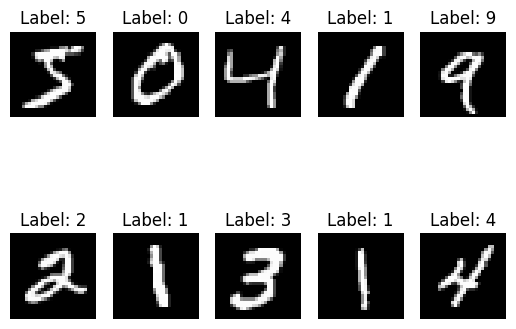

In [3]:
import matplotlib.pyplot as plt

# Display images with matplotlib
for i in range(1, 2):
    for j in range(10):
        plt.subplot(i + 1, 5, j + 1)
        plt.imshow(train_images[j], cmap='gray')
        plt.title(f"Label: {train_labels[j]}")
        plt.axis('off')

plt.show()

#### Step 2. Prepare the Data

Since the images are in grayscale and have pixel values ranging from 0 to 255, we need to normalize the pixel values to be between 0 and 1. This can be done by dividing the pixel values by 255. 

Additionally, we will flatten the 28x28 images into a 784-dimensional vector. Because Neural Networks typically expect the input data to be in a specific format like a 2D array of `(number_of_samples, number_of_features)`, we will reshape the data accordingly.

In [4]:
# Reshape image to (28,28) -> (784,)
train_images = train_images.reshape((60000, 28 * 28))
test_images = test_images.reshape((10000, 28 * 28))
print("Train Images Shape:", train_images.shape)
print("Test Images Shape:", test_images.shape)

# Normalize data
train_images = train_images.astype("float32") / 255
test_images = test_images.astype("float32") / 255

Train Images Shape: (60000, 784)
Test Images Shape: (10000, 784)


#### Step 3. Build the Model

We define the architecture of our neural network. 

- Two hidden layers with 512 and 256 neurons respectively, using the ReLU activation function.
- An output layer with 10 neurons (one for each digit) using the softmax activation function.
- Use keras Sequential API to build the model.

In [5]:
from tensorflow import keras
from tensorflow.keras import layers

# Build the model
hidden_layer1 = layers.Dense(512, activation="relu")
hidden_layer2 = layers.Dense(256, activation="relu")
output_layer = layers.Dense(10, activation="softmax")

model = keras.Sequential([hidden_layer1, hidden_layer2,
                          output_layer])

#### Step 4. Compile the Model

We need to compile the model before training it. This involves specifying the loss function, optimizer, and metrics to evaluate during training.

This is the stage backpropagation is applied to adjust the weights of the network based on the error calculated from the loss function.

In [6]:
# Compile the model
model.compile(optimizer="rmsprop",
              loss="sparse_categorical_crossentropy",
              metrics=["accuracy"])

#### Step 5. Train and Validate the Model

Now that the model is compiled, we can train it using the training data. The validation data will be used to monitor the model's performance on unseen data during training.

- Epochs: 20 meaning the model will go through the entire training dataset 20 times.
- Batch size: 128 meaning the model will update its weights after processing 128 samples.
- 20% of the training data will be used for validation during training.

In [7]:
# Fit the model
model.fit(train_images, train_labels, epochs=20, batch_size=128, validation_split=0.2)

Epoch 1/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9199 - loss: 0.2630 - val_accuracy: 0.9644 - val_loss: 0.1184
Epoch 2/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9698 - loss: 0.0973 - val_accuracy: 0.9721 - val_loss: 0.0914
Epoch 3/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9807 - loss: 0.0616 - val_accuracy: 0.9729 - val_loss: 0.0936
Epoch 4/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9861 - loss: 0.0438 - val_accuracy: 0.9794 - val_loss: 0.0728
Epoch 5/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9896 - loss: 0.0311 - val_accuracy: 0.9746 - val_loss: 0.0929
Epoch 6/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9933 - loss: 0.0221 - val_accuracy: 0.9729 - val_loss: 0.1143
Epoch 7/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9947 - loss: 0.0167 - val_accuracy: 0.9793 - val_loss: 0.0902
Epoch 8/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9956 - loss: 0.0128 - val_accuracy: 0.

#### Step 6. Fit the Model and Monitor Performance

The history object returned by the `fit` method contains the training and validation loss and accuracy for each epoch, which we can use to visualize the training process.

`[-1]` means we are accessing the last epoch's performance metrics, which gives us the final training and validation accuracy after the model has been trained for all epochs.

In [8]:
# Record the model in history
history = model.history
# Print the train loss, validation loss, train accuracy, validation accuracy
print("Train Loss:", history.history["loss"][-1])
print("Validation Loss:", history.history["val_loss"][-1])
print("Train Accuracy:", history.history["accuracy"][-1])
print("Validation Accuracy:", history.history["val_accuracy"][-1])

Train Loss: 1.7009713701554574e-05
Validation Loss: 0.10636517405509949
Train Accuracy: 1.0
Validation Accuracy: 0.9830833077430725


#### Step 7. Select the Best Model (Epoch Selection)

We visualize the training and validation accuracy and loss over epochs to determine if the model is overfitting or underfitting. We can select the epoch with the best validation performance as our final model.

**Pro Tip: Chooses the epoch where the validation loss is lowest and validation accuracy is highest to avoid overfitting.**

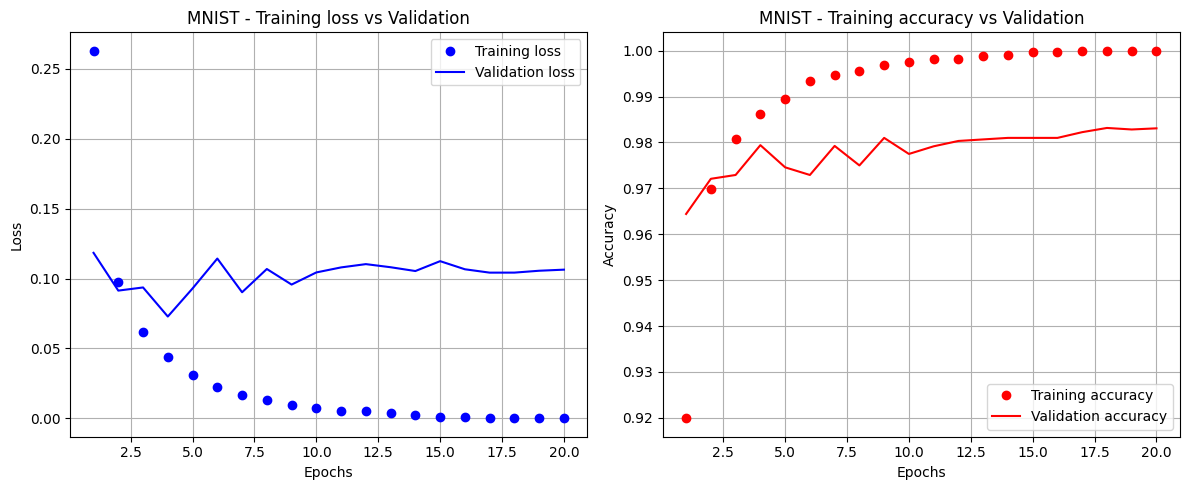

In [9]:
# Plot the Train Loss, Validation Loss, Train Accuracy, Validation Accuracy
import matplotlib.pyplot as plt


loss = history.history['loss']
val_loss = history.history['val_loss']
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
epochs = range(1, len(loss) + 1)

fig, ax = plt.subplots(1, 2, figsize=(12, 5))
ax[0].plot(epochs, loss, 'bo', label='Training loss')
ax[0].plot(epochs, val_loss, 'b', label='Validation loss')
ax[0].set_title('MNIST - Training loss vs Validation')
ax[0].set_xlabel('Epochs')
ax[0].set_ylabel('Loss')
ax[0].legend()
ax[0].grid(True)

ax[1].plot(epochs, acc, 'ro', label='Training accuracy')
ax[1].plot(epochs, val_acc, 'r', label='Validation accuracy')
ax[1].set_title('MNIST - Training accuracy vs Validation')
ax[1].set_xlabel('Epochs')
ax[1].set_ylabel('Accuracy')
ax[1].legend()
ax[1].grid(True)

plt.tight_layout()
plt.show()

#### Step 8. Evaluate on the Test Set

After selecting the best model based on validation performance, we evaluate its performance on the test set to see how well it generalizes to unseen data.

We use the `argmax` function to convert the predicted probabilities into class labels and then calculate the test accuracy by taking the mean.

In [10]:
import numpy as np

# Evaluate on test set
y_pred = model.predict(test_images)
y_pred = np.argmax(y_pred, axis=1)
print("Test Accuracy:", np.mean(y_pred == test_labels))
print("Test Loss:", model.evaluate(test_images, test_labels)[0])

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 596us/step
Test Accuracy: 0.9846
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 704us/step - accuracy: 0.9846 - loss: 0.0891
Test Loss: 0.08912696689367294


#### Step 9. Prediction

Finally, we can use the trained model to make predictions on new data. We can take a sample from the test set, pass it through the model, and compare the predicted label with the true label to see how well our model performs on individual samples.

Prediction: 7, True Label: 7
Prediction: 2, True Label: 2
Prediction: 1, True Label: 1
Prediction: 0, True Label: 0
Prediction: 4, True Label: 4
Prediction: 1, True Label: 1
Prediction: 4, True Label: 4
Prediction: 9, True Label: 9
Prediction: 5, True Label: 5
Prediction: 9, True Label: 9


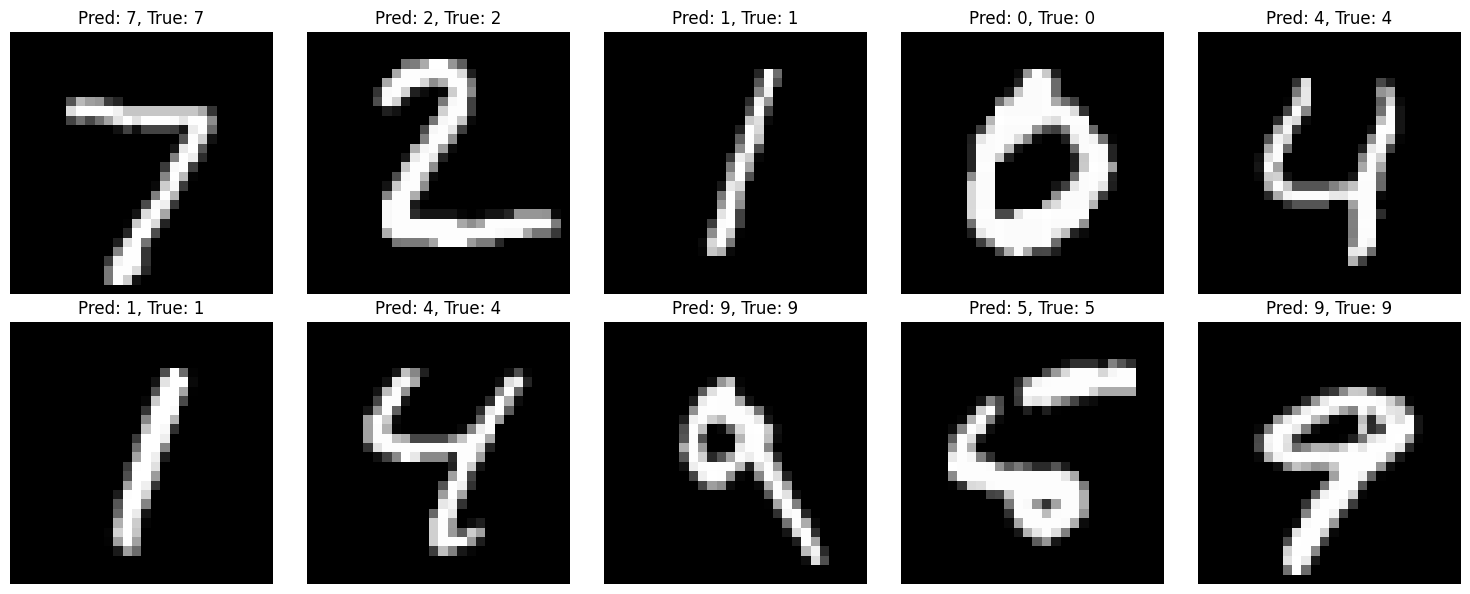

In [11]:
# Predict on new images
import numpy as np
import matplotlib.pyplot as plt

# Get the first 10 images from the test set
new_images = test_images[:10]
new_labels = test_labels[:10]

# Create a figure and a 2x5 subplot grid
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
axes = axes.flatten() # Flatten the 2x5 array of axes for easy iteration

# Predict for each image and display the result
for i in range(10):
    current_image = new_images[i]
    true_label = new_labels[i]
    # Reshape to match the model's input shape (1, 28 * 28)
    image_input = current_image.reshape(1, 28 * 28)
    prediction = model.predict(image_input, verbose=0)
    predicted_label = prediction[0].argmax()

    print(f"Prediction: {predicted_label}, True Label: {true_label}")

    # Display the image in the subplot
    axes[i].imshow(current_image.reshape(28, 28), cmap='gray')
    axes[i].set_title(f"Pred: {predicted_label}, True: {true_label}")
    axes[i].axis('off')

plt.tight_layout() # Adjust layout to prevent overlapping titles/labels
plt.show()

#### Optional: Retraining the model

If the model's performance is not satisfactory, we can consider retraining it with different hyperparameters, such as increasing the number of epochs, changing the batch size, or modifying the architecture of the neural network. This iterative process can help improve the model's performance on the test set.

The epoch with the best validation performance can be selected as the final model, and we can evaluate its performance on the test set to see how well it generalizes to unseen data.

In [12]:
# Retrain the model with the optimal epoch
model = keras.Sequential([hidden_layer1, hidden_layer2,
                          output_layer])
model.compile(optimizer="rmsprop",
              loss="sparse_categorical_crossentropy",
              metrics=["accuracy"])
# Based on the plot, we choose epoch=4
model.fit(train_images, train_labels, epochs=4, batch_size=128, validation_split=0.2)
# Compute loss
y_pred = model.predict(test_images)
y_pred = np.argmax(y_pred, axis=1)
print("Test Accuracy:", np.mean(y_pred == test_labels))
print("Test Loss:", model.evaluate(test_images, test_labels)[0])

Epoch 1/4
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 1.0000 - loss: 1.5070e-05 - val_accuracy: 0.9830 - val_loss: 0.1068
Epoch 2/4
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 1.0000 - loss: 1.3628e-05 - val_accuracy: 0.9832 - val_loss: 0.1077
Epoch 3/4
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 1.0000 - loss: 1.2504e-05 - val_accuracy: 0.9829 - val_loss: 0.1080
Epoch 4/4
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 1.0000 - loss: 1.1536e-05 - val_accuracy: 0.9831 - val_loss: 0.1088
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 843us/step
Test Accuracy: 0.9848
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 707us/step - accuracy: 0.9848 - loss: 0.0908
Test Loss: 0.09081248193979263


### Recap
1. Load the Data
2. Prepare the Data
3. Build the Model
4. Compile the Model
5. Train and Validate the Model
6. Fit the Model and Monitor Performance
7. Select the Best Model (Epoch Selection)
8. Evaluate on the Test Set
9. Prediction
10. Optional: Retraining the model